In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vencerlanz09/sea-animals-image-dataste")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sea-animals-image-dataste' dataset.
Path to dataset files: /kaggle/input/sea-animals-image-dataste


In [ ]:
import tensorflow as tf

gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print('GPU is available:')
    for gpu in gpu_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
        print(gpu)
    # Optional: Run nvidia-smi for more detailed GPU info
    !nvidia-smi
else:
    print('No GPU devices found. Training will run on CPU.')

GPU is available:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Mon Jun  1 11:24:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             30W /   70W |    4221MiB /  15360MiB |      0%      Default |
|                                         |              

In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Assuming 'path' from the previous kagglehub download points to the dataset root
dataset_path = path # Adjust if structure is different

image_size = (224, 224) # DenseNet typically expects 224x224 input
batch_size = 32

# Data augmentation and preprocessing for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # Use 20% of data for validation
)

# Only rescaling for validation/test data
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create training generator
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Create validation generator
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

num_classes = train_generator.num_classes
print(f"Found {num_classes} classes.")

Found 10979 images belonging to 23 classes.
Found 2732 images belonging to 23 classes.
Found 23 classes.


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load the DenseNet121 model with pre-trained ImageNet weights, excluding the top (classification) layer
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))

# Freeze the base model layers to prevent re-training during initial phase
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x) # num_classes from data prep

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

# Train the model
epochs = 20 # You can adjust the number of epochs
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 8,110,679 (30.94 MB)

 Trainable params: 1,073,175 (4.09 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 238s 627ms/step - accuracy: 0.5701 - loss: 1.5502 - val_accuracy: 0.7075 - val_loss: 0.9843
Epoch 2/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 184s 534ms/step - accuracy: 0.7304 - loss: 0.9261 - val_accuracy: 0.7500 - val_loss: 0.8233
Epoch 3/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 183s 531ms/step - accuracy: 0.7549 - loss: 0.8148 - val_accuracy: 0.7624 - val_loss: 0.8022
Epoch 4/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 184s 536ms/step - accuracy: 0.7716 - loss: 0.7516 - val_accuracy: 0.7646 - val_loss: 0.7519
Epoch 5/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 181s 525ms/step - accuracy: 0.7847 - loss: 0.7137 - val_accuracy: 0.7690 - val_loss: 0.7723
Epoch 6/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 201s 524ms/step - accuracy: 0.7960 - loss: 0.6746 - val_accuracy: 0.7749 - val_loss: 0.7380
Epoch 7/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 203s 528ms/step - accuracy: 0.7931 - loss: 0.6666 - val_accuracy: 0.7826 - val_loss: 0.7087
Epoch 8/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 183s 532ms/step - accuracy: 0.8047 -

In [ ]:
import pandas as pd

# Convert the history object to a DataFrame for easier viewing
history_df = pd.DataFrame(history.history)

print("Training History Summary:")
display(history_df.head())
print(f"\nFinal Training Accuracy: {history_df['accuracy'].iloc[-1]:.4f}")
print(f"Final Validation Accuracy: {history_df['val_accuracy'].iloc[-1]:.4f}")
print(f"Final Training Loss: {history_df['loss'].iloc[-1]:.4f}")
print(f"Final Validation Loss: {history_df['val_loss'].iloc[-1]:.4f}")

Training History Summary:


,accuracy,loss,val_accuracy,val_loss
0,0.570088,1.550174,0.707540,0.984308
1,0.730394,0.926120,0.750000,0.823274
2,0.754896,0.814781,0.762445,0.802230
3,0.771564,0.751587,0.764641,0.751883
4,0.784680,0.713741,0.769034,0.772255



Final Training Accuracy: 0.8442
Final Validation Accuracy: 0.7859
Final Training Loss: 0.4988
Final Validation Loss: 0.6988


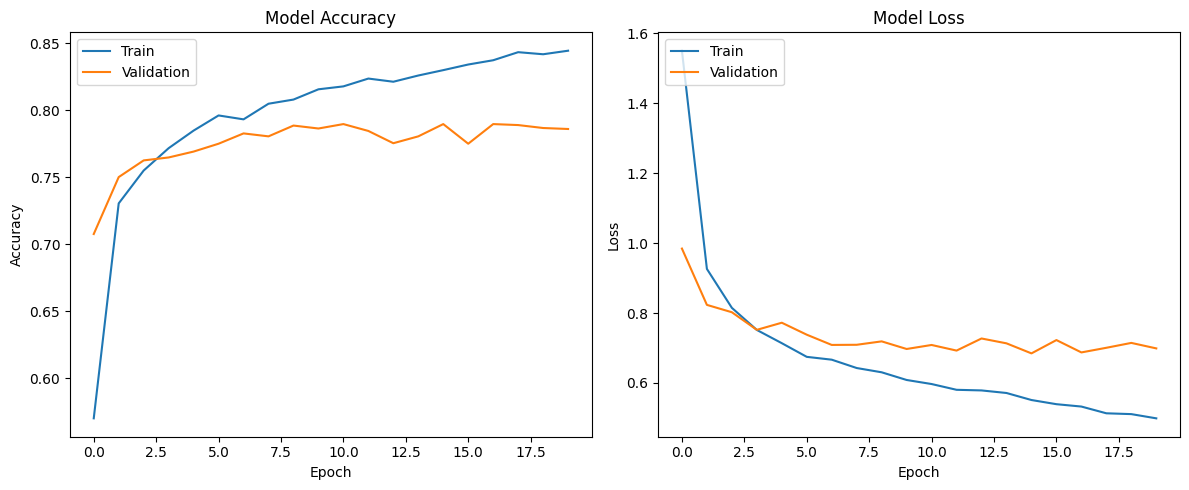

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()